In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('ggplot')
sns.set_theme()

## 1. Tải dữ liệu về thông qua package

In [5]:
print("Đang tải dữ liệu MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Kích thước ban đầu: {X.shape}, nhãn: {np.unique(y)}")

mask = (y == 0) | (y == 1)
X_bin = X[mask]
y_bin = y[mask]

print(f"Kích thước sau khi lọc 0 và 1: {X_bin.shape}")
print(f"Phân bố nhãn: 0: {(y_bin==0).sum()}, 1: {(y_bin==1).sum()}")

Đang tải dữ liệu MNIST...
Kích thước ban đầu: (70000, 784), nhãn: [0 1 2 3 4 5 6 7 8 9]
Kích thước sau khi lọc 0 và 1: (14780, 784)
Phân bố nhãn: 0: 6903, 1: 7877


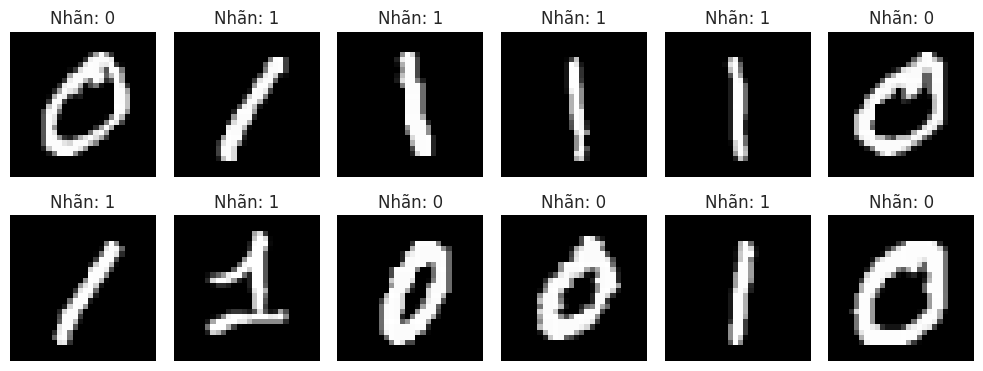

In [6]:
def plot_digits(images, labels, n_rows=2, n_cols=5):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].reshape(28, 28), cmap='gray')
        ax.set_title(f"Nhãn: {labels[i]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_digits(X_bin, y_bin, n_rows=2, n_cols=6)

## 2. EDA cơ bản

In [7]:
# Thống kê mô tả
print("=== THỐNG KÊ MÔ TẢ DỮ LIỆU ===")
print(f"Tổng số mẫu: {X_bin.shape[0]}")
print(f"Số đặc trưng (pixel): {X_bin.shape[1]}")
print(f"Giá trị pixel min: {X_bin.min():.0f}, max: {X_bin.max():.0f}")
print(f"Trung bình pixel toàn tập: {X_bin.mean():.2f}")
print(f"Độ lệch chuẩn pixel toàn tập: {X_bin.std():.2f}")
print("\nPhân bố nhãn:")
print(f"  Lớp 0: {(y_bin==0).sum()} mẫu ({(y_bin==0).sum()/len(y_bin)*100:.1f}%)")
print(f"  Lớp 1: {(y_bin==1).sum()} mẫu ({(y_bin==1).sum()/len(y_bin)*100:.1f}%)")

=== THỐNG KÊ MÔ TẢ DỮ LIỆU ===
Tổng số mẫu: 14780
Số đặc trưng (pixel): 784
Giá trị pixel min: 0, max: 255
Trung bình pixel toàn tập: 30.98
Độ lệch chuẩn pixel toàn tập: 76.77

Phân bố nhãn:
  Lớp 0: 6903 mẫu (46.7%)
  Lớp 1: 7877 mẫu (53.3%)


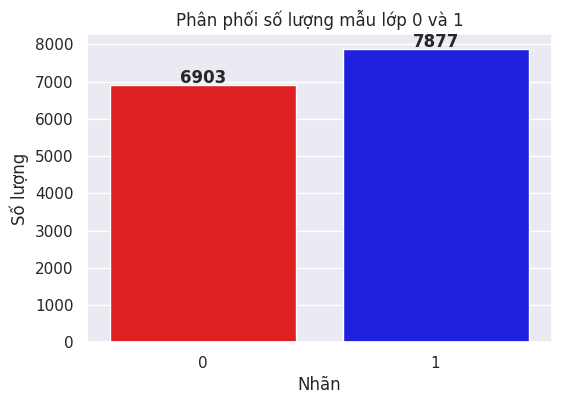

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_bin, palette=['red', 'blue'])
plt.title('Phân phối số lượng mẫu lớp 0 và 1')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks([0,1], ['0', '1'])
for i, count in enumerate([(y_bin==0).sum(), (y_bin==1).sum()]):
    plt.text(i, count+50, str(count), ha='center', fontweight='bold')
plt.show()

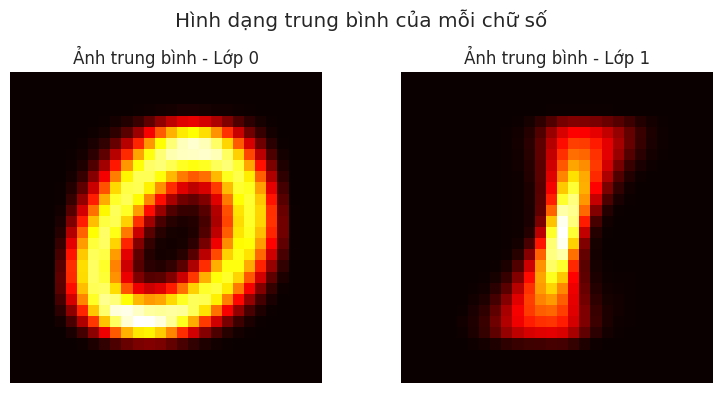

In [9]:
mean_img_0 = X_bin[y_bin==0].mean(axis=0).reshape(28,28)
mean_img_1 = X_bin[y_bin==1].mean(axis=0).reshape(28,28)

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(mean_img_0, cmap='hot')
axes[0].set_title('Ảnh trung bình - Lớp 0')
axes[0].axis('off')
axes[1].imshow(mean_img_1, cmap='hot')
axes[1].set_title('Ảnh trung bình - Lớp 1')
axes[1].axis('off')
plt.suptitle('Hình dạng trung bình của mỗi chữ số')
plt.tight_layout()
plt.show()

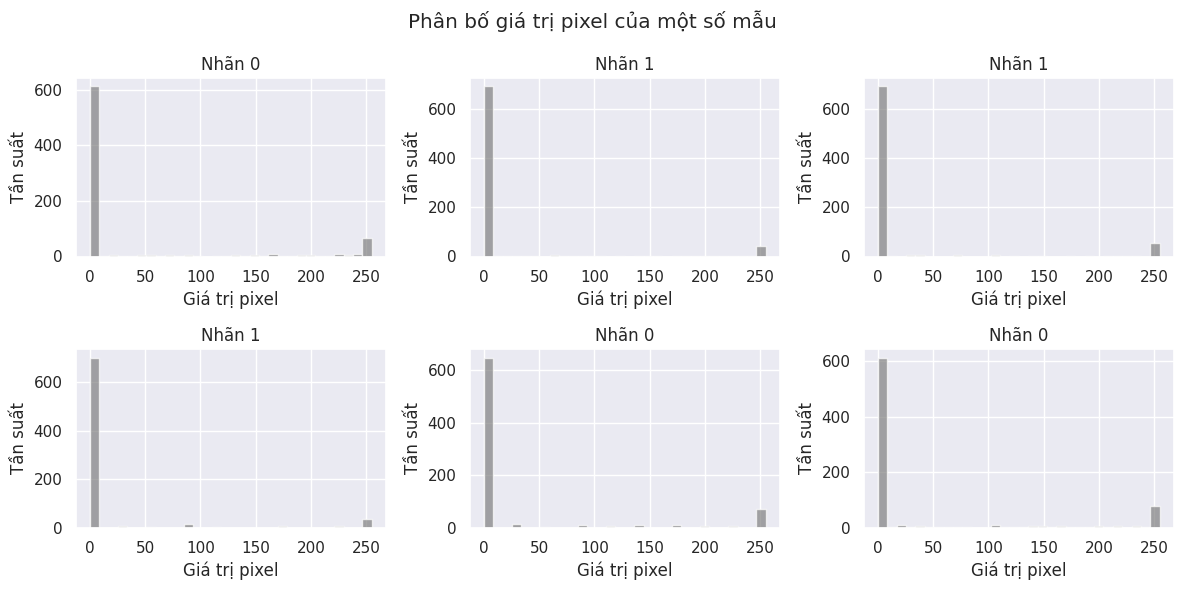

In [10]:
sample_indices = [0, 1, 2, 1000, 2000, 3000]
fig, axes = plt.subplots(2, 3, figsize=(12,6))
axes = axes.flat
for i, idx in enumerate(sample_indices):
    axes[i].hist(X_bin[idx], bins=30, color='gray', alpha=0.7)
    axes[i].set_title(f"Nhãn {y_bin[idx]}")
    axes[i].set_xlabel('Giá trị pixel')
    axes[i].set_ylabel('Tần suất')
plt.suptitle('Phân bố giá trị pixel của một số mẫu')
plt.tight_layout()
plt.show()

In [11]:
unique_samples = np.unique(X_bin, axis=0)
print(f"Số mẫu duy nhất: {unique_samples.shape[0]} / {X_bin.shape[0]}")
if unique_samples.shape[0] < X_bin.shape[0]:
    print(f"Có {X_bin.shape[0] - unique_samples.shape[0]} mẫu bị trùng lặp.")
else:
    print("Không có mẫu trùng lặp.")

Số mẫu duy nhất: 14780 / 14780
Không có mẫu trùng lặp.


## 3. Tiền xử lý dữ liệu

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 11824, Test size: 2956


## 4. Huấn luyện mô hình LinearSVC

### 4.1. Chạy `GridSearchCV`

In [13]:
from sklearn.model_selection import GridSearchCV

# Khai báo pipeline
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(random_state=42))
])

In [14]:
# Khai báo lưới tham số cho max_iter
param_grid = {
    'clf__C': [0.1, 0.2, 0.5, 1],
    'clf__max_iter': [1, 2, 3, 4, 5]
}

In [15]:
# GridSearchCV với cross-validation (cv=3)
grid = GridSearchCV(
    estimator=pipeline_linear,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,  
    verbose=1 
)

In [16]:
grid.fit(X_train, y_train)

print("=== KẾT QUẢ GRID SEARCH ===")
print(f"Tham số tốt nhất: {grid.best_params_}")
print(f"Độ chính xác CV tốt nhất: {grid.best_score_:.4f}")
print(f"Độ chính xác trên tập test: {grid.score(X_test, y_test):.4f}")

print("\n--- Chi tiết từng tổ hợp tham số ---")
results = grid.cv_results_
for mean_score, std_score, params in zip(
    results['mean_test_score'],
    results['std_test_score'],
    results['params']
):
    print(f"C={params['clf__C']:.1f}, max_iter={params['clf__max_iter']} -> "
          f"CV Accuracy: {mean_score:.4f} (+/- {std_score:.4f})")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
=== KẾT QUẢ GRID SEARCH ===
Tham số tốt nhất: {'clf__C': 0.1, 'clf__max_iter': 4}
Độ chính xác CV tốt nhất: 0.9988
Độ chính xác trên tập test: 0.9983

--- Chi tiết từng tổ hợp tham số ---
C=0.1, max_iter=1 -> CV Accuracy: 0.9935 (+/- 0.0005)
C=0.1, max_iter=2 -> CV Accuracy: 0.9981 (+/- 0.0011)
C=0.1, max_iter=3 -> CV Accuracy: 0.9986 (+/- 0.0009)
C=0.1, max_iter=4 -> CV Accuracy: 0.9988 (+/- 0.0007)
C=0.1, max_iter=5 -> CV Accuracy: 0.9986 (+/- 0.0006)
C=0.2, max_iter=1 -> CV Accuracy: 0.9935 (+/- 0.0005)
C=0.2, max_iter=2 -> CV Accuracy: 0.9981 (+/- 0.0011)
C=0.2, max_iter=3 -> CV Accuracy: 0.9986 (+/- 0.0009)
C=0.2, max_iter=4 -> CV Accuracy: 0.9988 (+/- 0.0007)
C=0.2, max_iter=5 -> CV Accuracy: 0.9985 (+/- 0.0007)
C=0.5, max_iter=1 -> CV Accuracy: 0.9935 (+/- 0.0005)
C=0.5, max_iter=2 -> CV Accuracy: 0.9981 (+/- 0.0011)
C=0.5, max_iter=3 -> CV Accuracy: 0.9986 (+/- 0.0009)
C=0.5, max_iter=4 -> CV Accuracy: 0.9988 (+/- 0.0

### 4.2. Huấn luyện

In [17]:
import time

# Tạo pipeline với tham số tốt nhất từ GridSearchCV
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(C=0.1, max_iter=4, random_state=42))
])

# Đo thời gian huấn luyện
start_time = time.time()
pipeline_linear.fit(X_train, y_train)
end_time = time.time()

# In kết quả
print(f"Thời gian huấn luyện: {end_time - start_time:.4f} giây")
print(f"Độ chính xác trên tập train: {pipeline_linear.score(X_train, y_train):.4f}")
print(f"Độ chính xác trên tập test: {pipeline_linear.score(X_test, y_test):.4f}")

Thời gian huấn luyện: 0.9874 giây
Độ chính xác trên tập train: 0.9996
Độ chính xác trên tập test: 0.9983


Accuracy LinearSVC: 0.9983

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1381
           1       1.00      1.00      1.00      1575

    accuracy                           1.00      2956
   macro avg       1.00      1.00      1.00      2956
weighted avg       1.00      1.00      1.00      2956



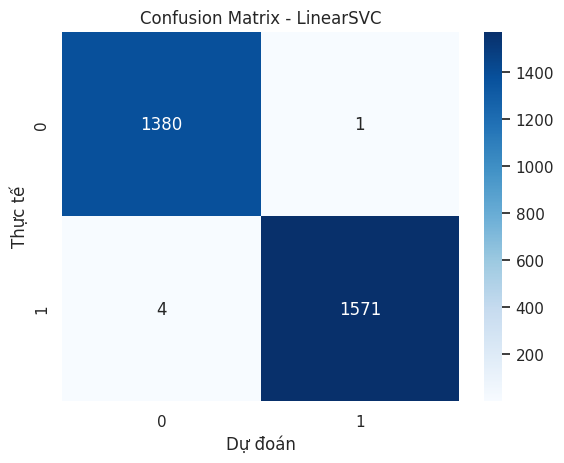

In [18]:
# Dự đoán và đánh giá
y_pred_linear = pipeline_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

print(f"Accuracy LinearSVC: {acc_linear:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

cm = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - LinearSVC')
plt.show()

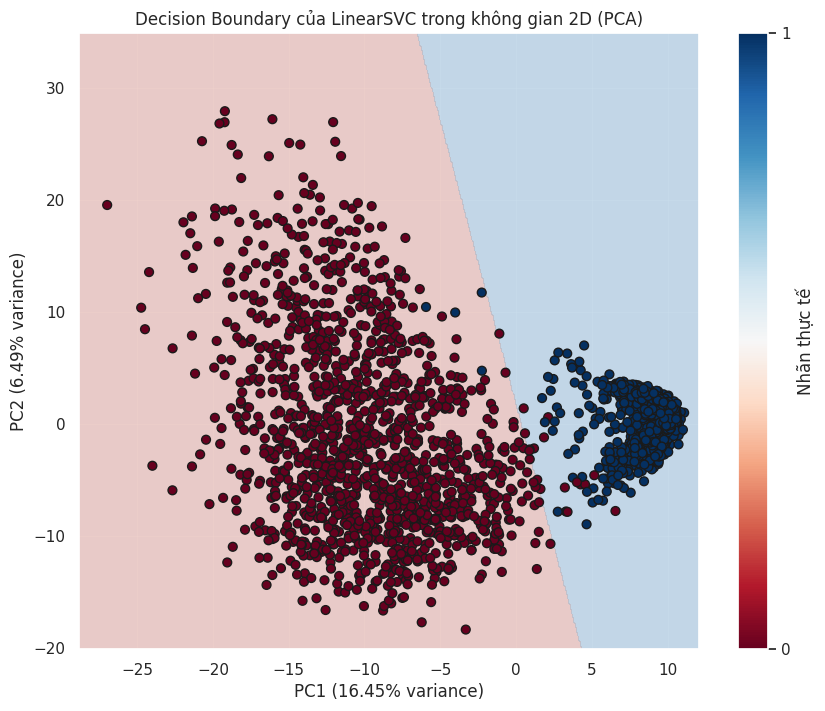

Lưu ý: Đường ranh giới trong không gian 2D chỉ là hình chiếu của siêu phẳng trong không gian gốc 784 chiều.


In [19]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X_train_scaled = pipeline_linear.named_steps['scaler'].transform(X_train)
X_test_scaled  = pipeline_linear.named_steps['scaler'].transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_original = pca.inverse_transform(grid_2d)  # về không gian đã chuẩn hóa
Z = pipeline_linear.named_steps['clf'].predict(grid_original)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu, levels=[-0.5, 0.5, 1.5])

scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                      c=y_test, cmap=plt.cm.RdBu, edgecolor='k', s=40)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Decision Boundary của LinearSVC trong không gian 2D (PCA)')
plt.colorbar(scatter, ticks=[0, 1], label='Nhãn thực tế')
plt.grid(alpha=0.2)
plt.show()

print("Lưu ý: Đường ranh giới trong không gian 2D chỉ là hình chiếu của siêu phẳng trong không gian gốc 784 chiều.")

## 5. Huấn luyện mô hình với SVM kernel RBF

In [20]:
# GridSearch cho LinearSVC
param_grid = {'clf__C': [0.01, 0.1, 1, 10]}
grid_linear = GridSearchCV(pipeline_linear, param_grid, cv=3, scoring='accuracy')
grid_linear.fit(X_train, y_train)

print(f"Best C: {grid_linear.best_params_}")
print(f"Best CV Accuracy: {grid_linear.best_score_:.4f}")
print(f"Test Accuracy: {grid_linear.score(X_test, y_test):.4f}")

Best C: {'clf__C': 0.01}
Best CV Accuracy: 0.9990
Test Accuracy: 0.9983


In [21]:
# Pipeline với SVC kernel RBF
pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=0.01, gamma='scale', random_state=42))
])

# Đo thời gian huấn luyện
start_time = time.time()
pipeline_rbf.fit(X_train, y_train)
end_time = time.time()

In [22]:
# Dự đoán và đánh giá
y_pred_rbf = pipeline_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Thời gian huấn luyện SVC (RBF): {end_time - start_time:.4f} giây")
print(f"Accuracy SVC (RBF): {acc_rbf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

Thời gian huấn luyện SVC (RBF): 28.2901 giây
Accuracy SVC (RBF): 0.9767

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      1381
           1       1.00      0.96      0.98      1575

    accuracy                           0.98      2956
   macro avg       0.98      0.98      0.98      2956
weighted avg       0.98      0.98      0.98      2956



## 6. So sánh các mô hình qua kiểm định thống kê

In [23]:
import numpy as np
from scipy.stats import ttest_rel
from statsmodels.stats.contingency_tables import mcnemar

In [24]:
# =============================================
# Paired t-test dựa trên cross‑validation
# =============================================

print("\n=== PAIRED T-TEST (dựa trên 5-fold CV) ===")
from sklearn.model_selection import cross_val_score

# Định nghĩa lại hai pipeline
pipe_lin = Pipeline([('scaler', StandardScaler()), ('clf', LinearSVC(C=0.1, max_iter=4, random_state=42))])
pipe_rbf = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=0.01, gamma='scale', random_state=42))])

# Tính 5-fold CV scores
cv_lin = cross_val_score(pipe_lin, X_train, y_train, cv=5, scoring='accuracy')
cv_rbf = cross_val_score(pipe_rbf, X_train, y_train, cv=5, scoring='accuracy')

print(f"LinearSVC CV scores: {cv_lin}")
print(f"RBF SVM CV scores  : {cv_rbf}")

t_stat, p_val = ttest_rel(cv_lin, cv_rbf)
print(f"Paired t-test: t = {t_stat:.4f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("→ Có sự khác biệt đáng kể giữa hai mô hình trên các fold.")
else:
    print("→ Không có sự khác biệt đáng kể.")


=== PAIRED T-TEST (dựa trên 5-fold CV) ===


LinearSVC CV scores: [1.         0.99830867 0.99957717 0.99830867 0.99957699]
RBF SVM CV scores  : [0.97885835 0.97970402 0.97885835 0.98224101 0.97884941]
Paired t-test: t = 20.3585, p = 0.0000
→ Có sự khác biệt đáng kể giữa hai mô hình trên các fold.
